In [1]:
import csv
import pandas # this is used to read the dataset
import time # this will be used to track the training time of the model
import torch # this will be the underlying framework of the model
import torch.amp # this will be used for faster processing on the gpu
from torch_geometric.nn import GCNConv, global_mean_pool # this will be used to create 
# the architecture of the model
from torch_geometric.data import Data, Batch, collate as collate_fn # Data acts like the training data while Batch allows for a higher amount of data
# to be passed to the model. Collate is what allows the batches of data to be properly fed to the model
from torch.utils.data import DataLoader, Dataset # this allows the creation and loading
# of the dataset
import rdkit.Chem # this will be used to convert the molecular formula (in the form of
# a SMILES) into a molecule for further processing

/home/jflop/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
h_receptors = ['NR-AR', 'NR-AR-LBD', 'NR-AhR',
               'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
               'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
               'SR-HSE', 'SR-MMP', 'SR-p53'] # this defines the 12 human receptors which the model will have to predict.

In [3]:
if torch.cuda.is_available():
    train_on = 'cuda' # this will use the gpu if possible
    scalar = torch.amp.GradScaler() # this is used to target AI cores on the gpu
else:
    train_on = 'cpu' # if the gpu isn't available, use the cpu

In [4]:
class Model(torch.nn.Module):
    def __init__(self, input_dimension, hidden_dimension, h_receptors): # this sets the model's parameters
        super().__init__() # send any commands to the parent class (torch.nn.Module) if necessary
        self.conv = GCNConv(input_dimension, hidden_dimension) # this will act as the backbone which will represent the molecular structure of
        # a given atom using the input_dimension as the input and outputting the output to the hidden dimension
        self.heads = torch.nn.ModuleList([torch.nn.Linear(hidden_dimension, 1) for _ in range(h_receptors)]) # for every receptor of a molecule, 
        # make one prediction.

    def forward(self, data):
        input = data.x # equates a variable, input, with the inputs from the data (as defined two code block above)
        molecule = data.edge_index # does the same thing except it used edges from data
        input = self.conv(input, molecule) # this combines the inputs (the molecular characteristics and edges) to create a graph 

        input = global_mean_pool(input, data.batch) # as it is, the input is the graphs/representations of the molecules. Using global_mean_pool
        # helps to "stack" these graphs together without losing their specific structures and characteristics
        logits = torch.cat([head(input) for head in self.heads], dim=1).squeeze(-1) # concatenate each of the model's predictions while returning a 
        # a scalar value (a tensor/matrix with 0 dimensions, i.e. a matrix with only one value)
        return logits # this returns whatever the value of logits is

In [5]:
model = Model(input_dimension=118, hidden_dimension=64, h_receptors=len(h_receptors)) # this sets the parameters of the model
model.to(train_on) # this moves the model to the gpu for training

Model(
  (conv): GCNConv(118, 64)
  (heads): ModuleList(
    (0-11): 12 x Linear(in_features=64, out_features=1, bias=True)
  )
)

In [6]:
# Inference (asking a model for their prediction)
state = torch.load('Tox21_model.pth', map_location=train_on, weights_only=False) # load the model
model.load_state_dict(state) # load the model's weights
model.eval() # set the model to training mode
model.to(train_on) # train on the GPU (if possible)

Model(
  (conv): GCNConv(118, 64)
  (heads): ModuleList(
    (0-11): 12 x Linear(in_features=64, out_features=1, bias=True)
  )
)

In [7]:
# Model inference  (asking the model to make predictions based on user input)

def predict_smiles(smiles, model, device): # this creates a function with three parameters and is similar to the dataset class created above
    mol = rdkit.Chem.MolFromSmiles(smiles) # get the molecule from the given SMILES
    
    if mol is None or mol.GetNumAtoms() == 0: # if a None value is given...
        return None # skip it
    
    number_of_atoms = mol.GetNumAtoms() # this gets the number of atoms in the molecule
    input = torch.zeros(number_of_atoms, 118, dtype=torch.float) # this creates a 118x118 matrix of 0. When an atom/element is accessed,
    # it fills a specific row with a value, which represents that specific atom. It does the same for the other atoms in the list, also
    # ensuring that each new element is given a separate column to properly represent all 118 elements in the periodic table.
            
    for i, atom in enumerate(mol.GetAtoms()): # enumerate assigns a an index value for each atom in the molecule
        atomic_number = atom.GetAtomicNum() - 1 # subtract one to preform 0-indexing (counting from 0 instead of 1)
        if 0 <= atomic_number < 118: # if the atomic number of an atom is in the given range ...
            input[i, atomic_number] = 1.0 # allocate the atom to a row in the matrix
    
    molecule_index_list = []
    for molecule in mol.GetBonds():
        beginning_of_molecule = molecule.GetBeginAtomIdx() # gets the beginning of the molecule
        ending_of_molecule = molecule.GetEndAtomIdx() # gets the end
        if isinstance(beginning_of_molecule, int) and isinstance(ending_of_molecule, int): # if there is an actual value for the beginning and ending
            # of the molecule...
            molecule_index_list.append([ending_of_molecule, beginning_of_molecule]) # append that information to the list of molecule indexes
            molecule_index_list.append([beginning_of_molecule, ending_of_molecule]) # make it bidirectional
    
    if len(molecule_index_list) == 0: # if the length of the molecule is 0...
        return None # return None
    
    molecule = torch.tensor(molecule_index_list, dtype=torch.long).t()#.contiguous() # this creates a matrix which represents the molecule while
    # switching the x and y axis in a way where the dataloader would prefer and makes it contiguous in memory (gives them a separate, continuous block
    # in a computer's memory)
    
    if molecule.shape[0] != 2: # if the shape of the first dimension of the molecule is not equal to (2, number of edges)...
        return None # return None
    
    
    data = Data(x=input, edge_index=molecule, batch=torch.zeros(len(input)), dtype=torch.long) # sets the data's parameters 
    data = data.to(device) # this moves data processes ideally to the GPU
    data.batch = torch.zeros(number_of_atoms, dtype=torch.long, device=device) # this defines data.batch as a matrix of zeros in the shape of 
    # number_of_atoms X number_of_atoms
    with torch.no_grad():
        logits = model(data).squeeze() # this removes all the data dimensions which have a size of 1 and assigns it to a variable name logits.
        # a logit is "the vector you get as output of the last layer of your neural network." source: https://markelic.de/what-is-a-logit/, accessed 8/14/26

        probability = torch.sigmoid(logits) # this is used to calculate probability by using sigmoid activation function.
        # Sigmoid is a mathematical function which is defined in th equation: σ(x) = 1/(1+e^-x) where σ is the name of the function (sigma) and 
        # e is euler's number.

    predictions = {} # create an empty dictionary of key : value pairs to store each prediction
    for i, receptors in enumerate(h_receptors): # for every receptor in the possible receptor list, given them an index and...
        if probability.numel() != len(h_receptors): # check if the probability has the model's predictions for each receptor.
            # if it doesn't, return this message
            return f'''Error: The number of elements in probability does not equal the number of elements
                       of available receptors.'''
        prob = float(probability[i].item()) * 10 # get everything from the i (which stands for the current iteration) dimension of probability and convert it into a
        # floating-point number
        logit = float(logits[i].item()) # get everything from logits 
        predictions[receptors] = { # for the current receptor, make a prediction which has the following:
            'probability': float(prob), # if called, return the float conversion of the probability value from prediction_probability
            'receptor': str(receptors), # if called, return the string (text) of receptor
            'predicted class': 1 if prob >= 0.5 else 0, # if the probability is high enough, make the prediction that the
            # molecule binds to a given receptor
            'logit': logit # if called, return the value of logit
        }
    return predictions # return the model's predictions

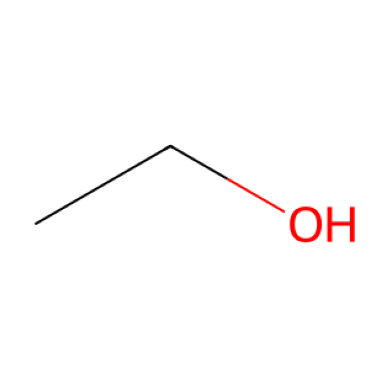

Prediction for: CCO
Receptor: NR-AR, Probability: 0.18101906403899193 (Inactive)
Receptor: NR-AR-LBD, Probability: 0.10974245145916939 (Inactive)
Receptor: NR-AhR, Probability: 0.2571415342390537 (Inactive)
Receptor: NR-Aromatase, Probability: 0.10842345654964447 (Inactive)
Receptor: NR-ER, Probability: 0.855918675661087 (Active)
Receptor: NR-ER-LBD, Probability: 0.17942920327186584 (Inactive)
Receptor: NR-PPAR-gamma, Probability: 0.10428780689835548 (Inactive)
Receptor: SR-ARE, Probability: 0.676334798336029 (Active)
Receptor: SR-ATAD5, Probability: 0.015304390108212829 (Inactive)
Receptor: SR-HSE, Probability: 0.0795468408614397 (Inactive)
Receptor: SR-MMP, Probability: 0.3193454444408417 (Inactive)
Receptor: SR-p53, Probability: 0.08861444890499115 (Inactive)


In [8]:
smiles = input("Enter a SMILES: ") # ask the user for an input
molecule_to_draw = rdkit.Chem.MolFromSmiles(smiles)

from rdkit.Chem.Draw import MolToImage # this imports a function which will be used to help render a 2d-skeletal structure of the molecule
image = MolToImage(molecule_to_draw) # this creates a variable, image, which will be then used to convert the molecule into an image

import matplotlib.pyplot as mpl # matplotplib is used to render the image
mpl.imshow(image) # show the image
mpl.axis('off') # hide all the axis so that only the molecule is rendered
mpl.show() # show the molecule

results = predict_smiles(smiles, model, train_on) # provide the SMILES, model, and training device to the predict_smiles function
print("Prediction for:", smiles)
for receptor, data in results.items(): # gets the model's prediction for each receptor in the data
    print(f"Receptor: {data['receptor']}, Probability: {data['probability']} ({'Active' if data['predicted class'] == 1 else 'Inactive'})")